# Astra-Torch Sanity Checks for Limited-Angle Time-Resolved Tomography

**Purpose:** Validate that `astra_torch.lamino` works correctly with our real projection data before using it in the Gaussian-splat time-resolved pipeline.

We use the **laminography** module with `lamino_angle_deg=0` to get standard 2D parallel-beam CT.
The 3D API lets us treat a 2D slice as a volume with `nz=1`: `vol_shape=(1, ny, nx)`, `det_shape=(1, W)`.

**Checks:**
1. Full-angle FBP reconstruction of each slice (all 1501 projections)
2. Build the limited-angle dataset (k=100 contiguous angles per slice, 15 slices)
3. Limited-angle FBP and gradient-descent reconstructions
4. Compare metrics: full-angle (reference) vs limited-angle

## 1. Imports and Setup

In [38]:
import sys, math, time, importlib
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torch

import lovely_tensors as lt
lt.monkey_patch()

# ── Project paths ─────────────────────────────────────────────────────────
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))
sys.path.insert(0, '/myhome/astra-torch')

import sdate.limited_angle_tomo as _lat_mod
importlib.reload(_lat_mod)

from sdate.limited_angle_tomo import (
    LimitedAngleConfig, build_limited_angle_dataset, normalize_sinogram,
)
from inct.dataset_slices import ProjectionSliceDataset

# ── Use lamino module (with lamino_angle_deg=0 for standard parallel beam) ──
from astra_torch.lamino import (
    build_lamino_projector,
    fbp_reconstruction_masked,
    sirt_reconstruction_masked,
    gd_reconstruction_masked,
)

# ── Laminography angle for standard 2D parallel-beam CT ───────────────────
# lamino_angle_deg=0 → rays in the xy-plane, which is standard parallel-beam
LAMINO_ANGLE_DEG = 0.0

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}  |  PyTorch {torch.__version__}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name()}")
print("✅ Imports ready (using astra_torch.lamino)")

Device: cuda  |  PyTorch 2.10.0+cu128
GPU: NVIDIA A100 80GB PCIe
✅ Imports ready (using astra_torch.lamino)


## 2. Load Full Projection Volume

In [24]:
# ── Configuration ─────────────────────────────────────────────────────────
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
NUM_PROJECTIONS = 1501       # Load all projections
TARGET_SIZE = (2560 // 2, 2160 // 2)  # Half resolution for speed

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=NUM_PROJECTIONS,
    target_size=TARGET_SIZE,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=False,
)

volume = dataset.get_full_volume()  # (H, W, N_proj)
H, W, N_proj = volume.shape
print(f"\nVolume loaded: ({H}, {W}, {N_proj})")
print(f"Value range: [{volume.min():.4f}, {volume.max():.4f}]")

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: False
✅ Loaded cached raw data from .tomography_cache_raw.npz
   Range: [6814.0000, 51523.0000]
ProjectionSliceDataset:
  Volume shape: (1080, 1280, 1501)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,382,400
Loading 1501 projections...
  Loaded 50/1501
  Loaded 100/1501
  Loaded 150/1501
  Loaded 200/1501
  Loaded 250/1501
  Loaded 300/1501
  Loaded 350/1501
  Loaded 400/1501
  Loaded 450/1501
  Loaded 500/1501
  Loaded 550/1501
  Loaded 600/1501
  Loaded 650/1501
  Loaded 700/1501
  Loaded 750/1501
  Loaded 800/1501
  Loaded 850/1501
  Loaded 900/1501
  Loaded 950/1501
  Loaded 1000/1501
  Loaded 1050/1501
  Loaded 1100/1501
  Loaded 1150/1501
  Loaded 1200/1501
  Loaded 1250/1501
  Loaded 1300/1501
  Loaded 1

## 3. Build Limited-Angle Dataset

Parameters:
- **n_slices = 15**: number of time steps
- **k_angles = 100**: contiguous angles per slice
- **total_projections = 1501**: wraps around, 15 × 100 = 1500 ≈ 1501

In [41]:
# ── Limited-angle dataset parameters (parametrised — adjust here) ─────────
N_SLICES = 15
K_ANGLES = 100
# Rows to skip between consecutive slices:
#   0          → consecutive rows 0,1,2,…,14  (maximum temporal coherence)
#   s > 0      → rows 0, 1+s, 2*(1+s), …      (sparser coverage)
#   H//N-1 ≈ 71 → ~uniform spread across the full volume height
HEIGHT_SKIP = 0

config = LimitedAngleConfig(
    n_slices=N_SLICES,
    k_angles=K_ANGLES,
    total_projections=N_proj,
    angular_range_deg=(0.0, 180.0),
    det_spacing_mm=1.0,
    voxel_size_mm=1.0,
    height_skip=HEIGHT_SKIP,
)

la_dataset = build_limited_angle_dataset(volume, config)

print(la_dataset.angle_coverage_summary())
print(f"\nVol shape for reconstruction: {la_dataset.vol_shape}")
print(f"Detector width: {la_dataset.W}")
print(f"Height stride: every {1 + HEIGHT_SKIP} row(s)  (skip={HEIGHT_SKIP})")

Limited-angle dataset: 15 slices, k=100 angles/slice, total=1501 projections
 Slice   Height   Angle start   Angle end   #Angles
-------------------------------------------------------
     0        0          0.00°       11.87°       100
     1        1         11.99°       23.86°       100
     2        2         23.98°       35.86°       100
     3        3         35.98°       47.85°       100
     4        4         47.97°       59.84°       100
     5        5         59.96°       71.83°       100
     6        6         71.95°       83.82°       100
     7        7         83.94°       95.82°       100
     8        8         95.94°      107.81°       100
     9        9        107.93°      119.80°       100
    10       10        119.92°      131.79°       100
    11       11        131.91°      143.78°       100
    12       12        143.90°      155.78°       100
    13       13        155.90°      167.77°       100
    14       14        167.89°      179.76°       100

Vol 

## 4. Full-Angle FBP Reconstruction (Reference)

Reconstruct each of the 15 slices using **all 1501 projections** — this is the gold-standard reference.

Using the lamino module with `vol_shape=(1, ny, nx)` and sinograms reshaped to `(V, 1, W)` for a single 2D slice.

In [26]:
# !pip install cupy-cuda11x

In [27]:
# ── Full-angle FBP reconstruction for all slices ──────────────────────────
# Using lamino with vol_shape=(1, ny, nx) to mimic 2D parallel beam
full_recons = []
ny, nx = la_dataset.vol_shape  # e.g. (W, W) — square
vol_shape_3d = (1, ny, nx)     # single z-slice for lamino

print(f"Reconstructing {N_SLICES} slices from all {N_proj} projections …")
print(f"  vol_shape_3d = {vol_shape_3d}  (1 z-slice)")
print(f"  lamino_angle = {LAMINO_ANGLE_DEG}° (standard parallel beam)")
t0 = time.time()

for i in range(N_SLICES):
    # Sinogram: (V, W) → (V, 1, W) to match lamino (V, R, C) convention
    sino_full = la_dataset.full_sinograms[i].to(device)  # (N_proj, W)
    sino_vrc = sino_full.unsqueeze(1)                     # (N_proj, 1, W)
    
    recon_3d = fbp_reconstruction_masked(
        projs_vrc=sino_vrc,
        angles_deg=la_dataset.all_angles_deg,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_3d,
        det_spacing_mm=config.det_spacing_mm,
        filter_type='hann',
        device=device,
    )
    # recon_3d: (1, ny, nx) → squeeze to (ny, nx)
    recon_2d = recon_3d[0]
    full_recons.append(recon_2d.cpu())
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  Slice {i+1}/{N_SLICES} done "
              f"[range: {recon_2d.min():.4f}, {recon_2d.max():.4f}]")

elapsed_full = time.time() - t0
full_recons = torch.stack(full_recons, dim=0)  # (N_SLICES, ny, nx)
print(f"\n✅ Full-angle FBP done in {elapsed_full:.1f}s")
print(f"   Reconstruction stack: {full_recons.shape}")

Reconstructing 15 slices from all 1501 projections …
  vol_shape_3d = (1, 1280, 1280)  (1 z-slice)
  lamino_angle = 0.0° (standard parallel beam)
  Slice 1/15 done [range: -79.7209, 49.4855]
  Slice 5/15 done [range: -74.8133, 51.5967]
  Slice 10/15 done [range: -91.2499, 50.8745]
  Slice 15/15 done [range: -73.2880, 51.8596]

✅ Full-angle FBP done in 0.9s
   Reconstruction stack: torch.Size([15, 1280, 1280])


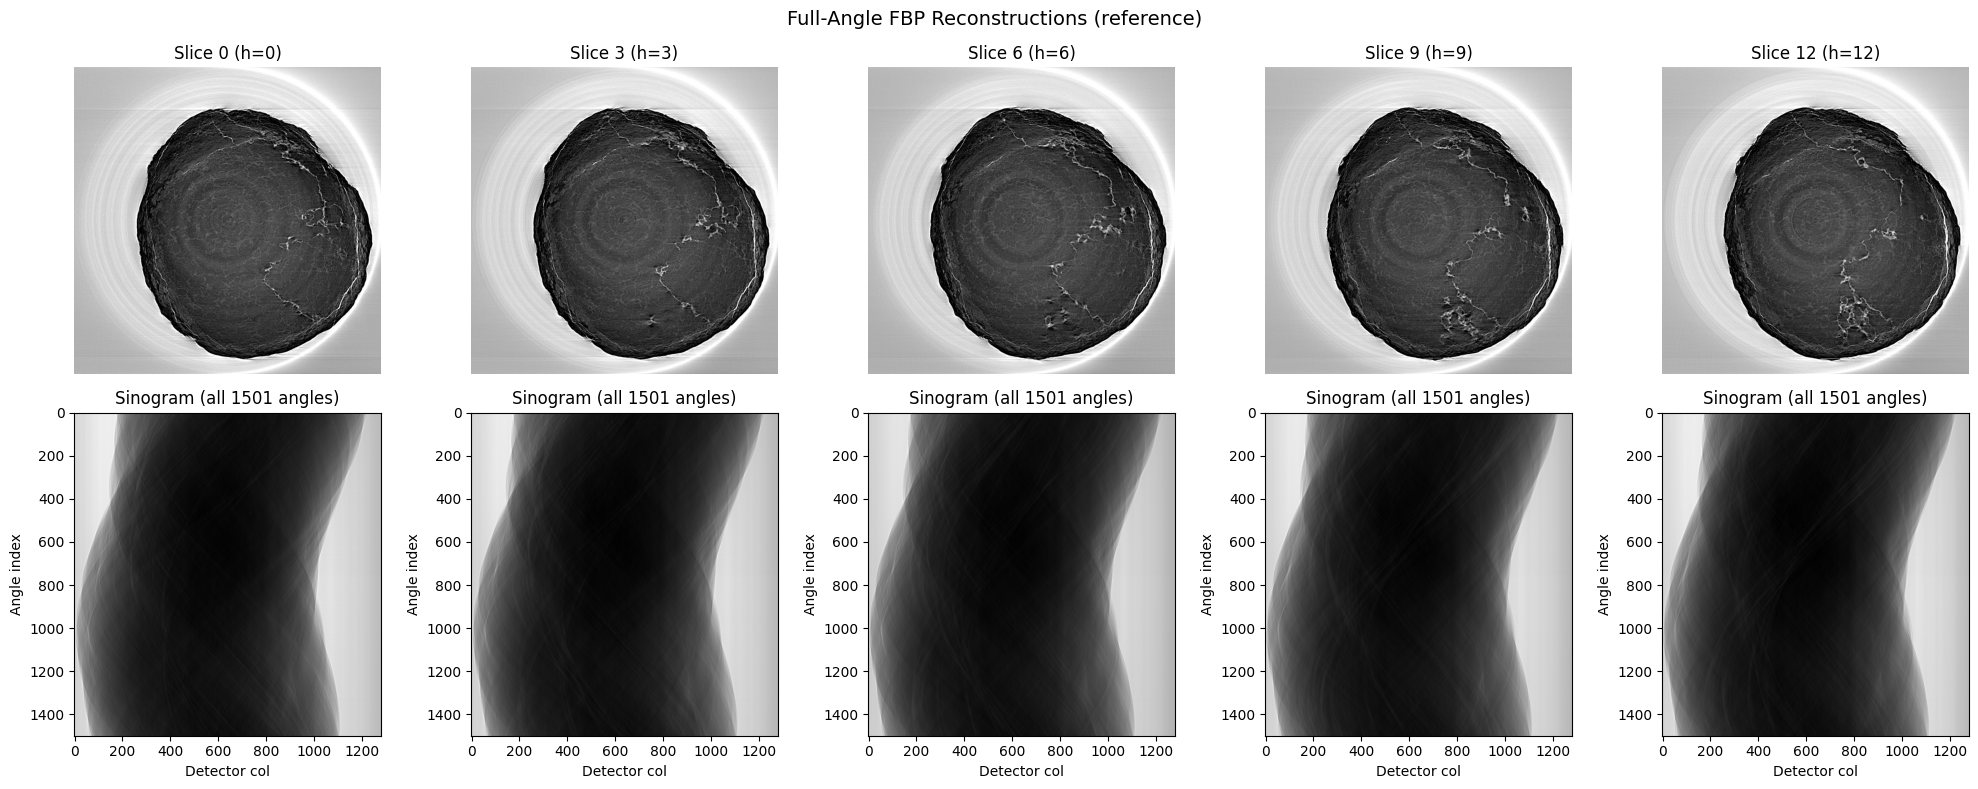

In [28]:
# ── Visualise full-angle reconstructions ──────────────────────────────────
n_show = min(5, N_SLICES)
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

for j in range(n_show):
    idx = j * (N_SLICES // n_show) if n_show < N_SLICES else j
    img = full_recons[idx].numpy()
    vmin, vmax = np.percentile(img, [2, 98])
    
    axes[0, j].imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, j].set_title(f'Slice {idx} (h={la_dataset.height_indices[idx]})')
    axes[0, j].axis('off')
    
    # Show the sinogram
    sino_np = la_dataset.full_sinograms[idx].numpy()
    axes[1, j].imshow(sino_np, cmap='gray', aspect='auto')
    axes[1, j].set_title(f'Sinogram (all {N_proj} angles)')
    axes[1, j].set_xlabel('Detector col')
    axes[1, j].set_ylabel('Angle index')

plt.suptitle('Full-Angle FBP Reconstructions (reference)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Limited-Angle FBP Reconstruction

Now reconstruct using only the **k contiguous angles** available to each slice.

In [29]:
# ── Limited-angle FBP reconstruction ──────────────────────────────────────
limited_fbp_recons = []

print(f"Limited-angle FBP: {K_ANGLES} angles per slice …")
t0 = time.time()

for i in range(N_SLICES):
    sino_limited = la_dataset.limited_sinograms[i].to(device)  # (k, W)
    sino_vrc = sino_limited.unsqueeze(1)                        # (k, 1, W)
    angles_limited = la_dataset.slice_angles_deg[i]
    
    recon_3d = fbp_reconstruction_masked(
        projs_vrc=sino_vrc,
        angles_deg=angles_limited,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_3d,
        det_spacing_mm=config.det_spacing_mm,
        filter_type='hann',
        device=device,
    )
    limited_fbp_recons.append(recon_3d[0].cpu())

elapsed_la_fbp = time.time() - t0
limited_fbp_recons = torch.stack(limited_fbp_recons, dim=0)
print(f"✅ Limited-angle FBP done in {elapsed_la_fbp:.1f}s")

Limited-angle FBP: 100 angles per slice …
✅ Limited-angle FBP done in 0.1s


## 6. Limited-Angle Gradient Descent Reconstruction

Use the differentiable projector + Adam optimizer for iterative reconstruction.
This should handle the limited-angle case better than FBP.

In [37]:
# ── Limited-angle GD reconstruction ───────────────────────────────────────
limited_gd_recons = []

# GD hyperparameters
GD_EPOCHS = [30, 20]
GD_BATCH = [20, 20]
GD_LR = [5e-0, 1e-0]

print(f"Limited-angle GD: {K_ANGLES} angles, epochs={GD_EPOCHS}, lr={GD_LR} …")
t0 = time.time()

for i in range(N_SLICES):
    sino_limited = la_dataset.limited_sinograms[i].to(device)  # (k, W)
    sino_vrc = sino_limited.unsqueeze(1)                        # (k, 1, W)
    angles_limited = la_dataset.slice_angles_deg[i]
    
    recon_3d = gd_reconstruction_masked(
        projs_vrc=sino_vrc,
        angles_deg=angles_limited,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_3d,
        det_spacing_mm=config.det_spacing_mm,
        max_epochs=GD_EPOCHS,
        batch_size=GD_BATCH,
        lr=GD_LR,
        clamp_min=0.0,
        optimizer_type="adam",
        device=device,
        verbose=True,
    )
    limited_gd_recons.append(recon_3d[0].cpu())
    if (i + 1) % 5 == 0 or i == 0:
        print(f"  Slice {i+1}/{N_SLICES} done")

elapsed_la_gd = time.time() - t0
limited_gd_recons = torch.stack(limited_gd_recons, dim=0)
print(f"✅ Limited-angle GD done in {elapsed_la_gd:.1f}s")

Limited-angle GD: 100 angles, epochs=[30, 20], lr=[5.0, 1.0] …


  Slice 1/15 done
  Slice 5/15 done
  Slice 10/15 done
  Slice 15/15 done
✅ Limited-angle GD done in 32.8s


## 7. Metrics Comparison

In [31]:
from skimage.metrics import structural_similarity

def compute_psnr(recon, ref):
    """Compute PSNR between recon and ref (numpy arrays)."""
    mse_val = np.mean((recon - ref) ** 2)
    if mse_val < 1e-12:
        return 100.0
    data_range = ref.max() - ref.min()
    return 10.0 * np.log10(data_range ** 2 / mse_val)

def compute_ssim(recon, ref):
    """Compute SSIM between recon and ref."""
    data_range = ref.max() - ref.min()
    return structural_similarity(ref, recon, data_range=data_range)

# ── Compute metrics per slice ─────────────────────────────────────────────
metrics = []
print(f"{'Slice':>6}  {'Height':>7}  "
      f"{'FBP-LA PSNR':>12}  {'FBP-LA SSIM':>12}  "
      f"{'GD-LA PSNR':>11}  {'GD-LA SSIM':>11}")
print("-" * 75)

for i in range(N_SLICES):
    ref = full_recons[i].numpy()
    fbp_la = limited_fbp_recons[i].numpy()
    gd_la = limited_gd_recons[i].numpy()
    
    psnr_fbp = compute_psnr(fbp_la, ref)
    ssim_fbp = compute_ssim(fbp_la, ref)
    psnr_gd = compute_psnr(gd_la, ref)
    ssim_gd = compute_ssim(gd_la, ref)
    
    metrics.append({
        'slice': i,
        'height': int(la_dataset.height_indices[i]),
        'psnr_fbp_la': psnr_fbp,
        'ssim_fbp_la': ssim_fbp,
        'psnr_gd_la': psnr_gd,
        'ssim_gd_la': ssim_gd,
    })
    
    print(f"{i:>6d}  {int(la_dataset.height_indices[i]):>7d}  "
          f"{psnr_fbp:>12.2f}  {ssim_fbp:>12.4f}  "
          f"{psnr_gd:>11.2f}  {ssim_gd:>11.4f}")

# ── Averages ──────────────────────────────────────────────────────────────
avg_psnr_fbp = np.mean([m['psnr_fbp_la'] for m in metrics])
avg_ssim_fbp = np.mean([m['ssim_fbp_la'] for m in metrics])
avg_psnr_gd = np.mean([m['psnr_gd_la'] for m in metrics])
avg_ssim_gd = np.mean([m['ssim_gd_la'] for m in metrics])

print("-" * 75)
print(f"{'AVG':>6}  {'':>7}  "
      f"{avg_psnr_fbp:>12.2f}  {avg_ssim_fbp:>12.4f}  "
      f"{avg_psnr_gd:>11.2f}  {avg_ssim_gd:>11.4f}")

 Slice   Height   FBP-LA PSNR   FBP-LA SSIM   GD-LA PSNR   GD-LA SSIM
---------------------------------------------------------------------------
     0        0         11.50        0.1262        17.33       0.1520
     1        1         11.68        0.1587        17.16       0.1586
     2        2         12.05        0.1757        17.12       0.1528
     3        3         11.45        0.1907        17.21       0.1535
     4        4         11.30        0.1940        17.10       0.1526
     5        5         10.96        0.1801        16.81       0.1534
     6        6         11.20        0.1679        17.23       0.1528
     7        7         10.86        0.1349        16.95       0.1411
     8        8         11.00        0.1450        17.00       0.1552
     9        9         13.01        0.1698        18.07       0.1773
    10       10         13.13        0.1670        17.91       0.1769
    11       11         12.33        0.1366        16.79       0.1581
    12       1

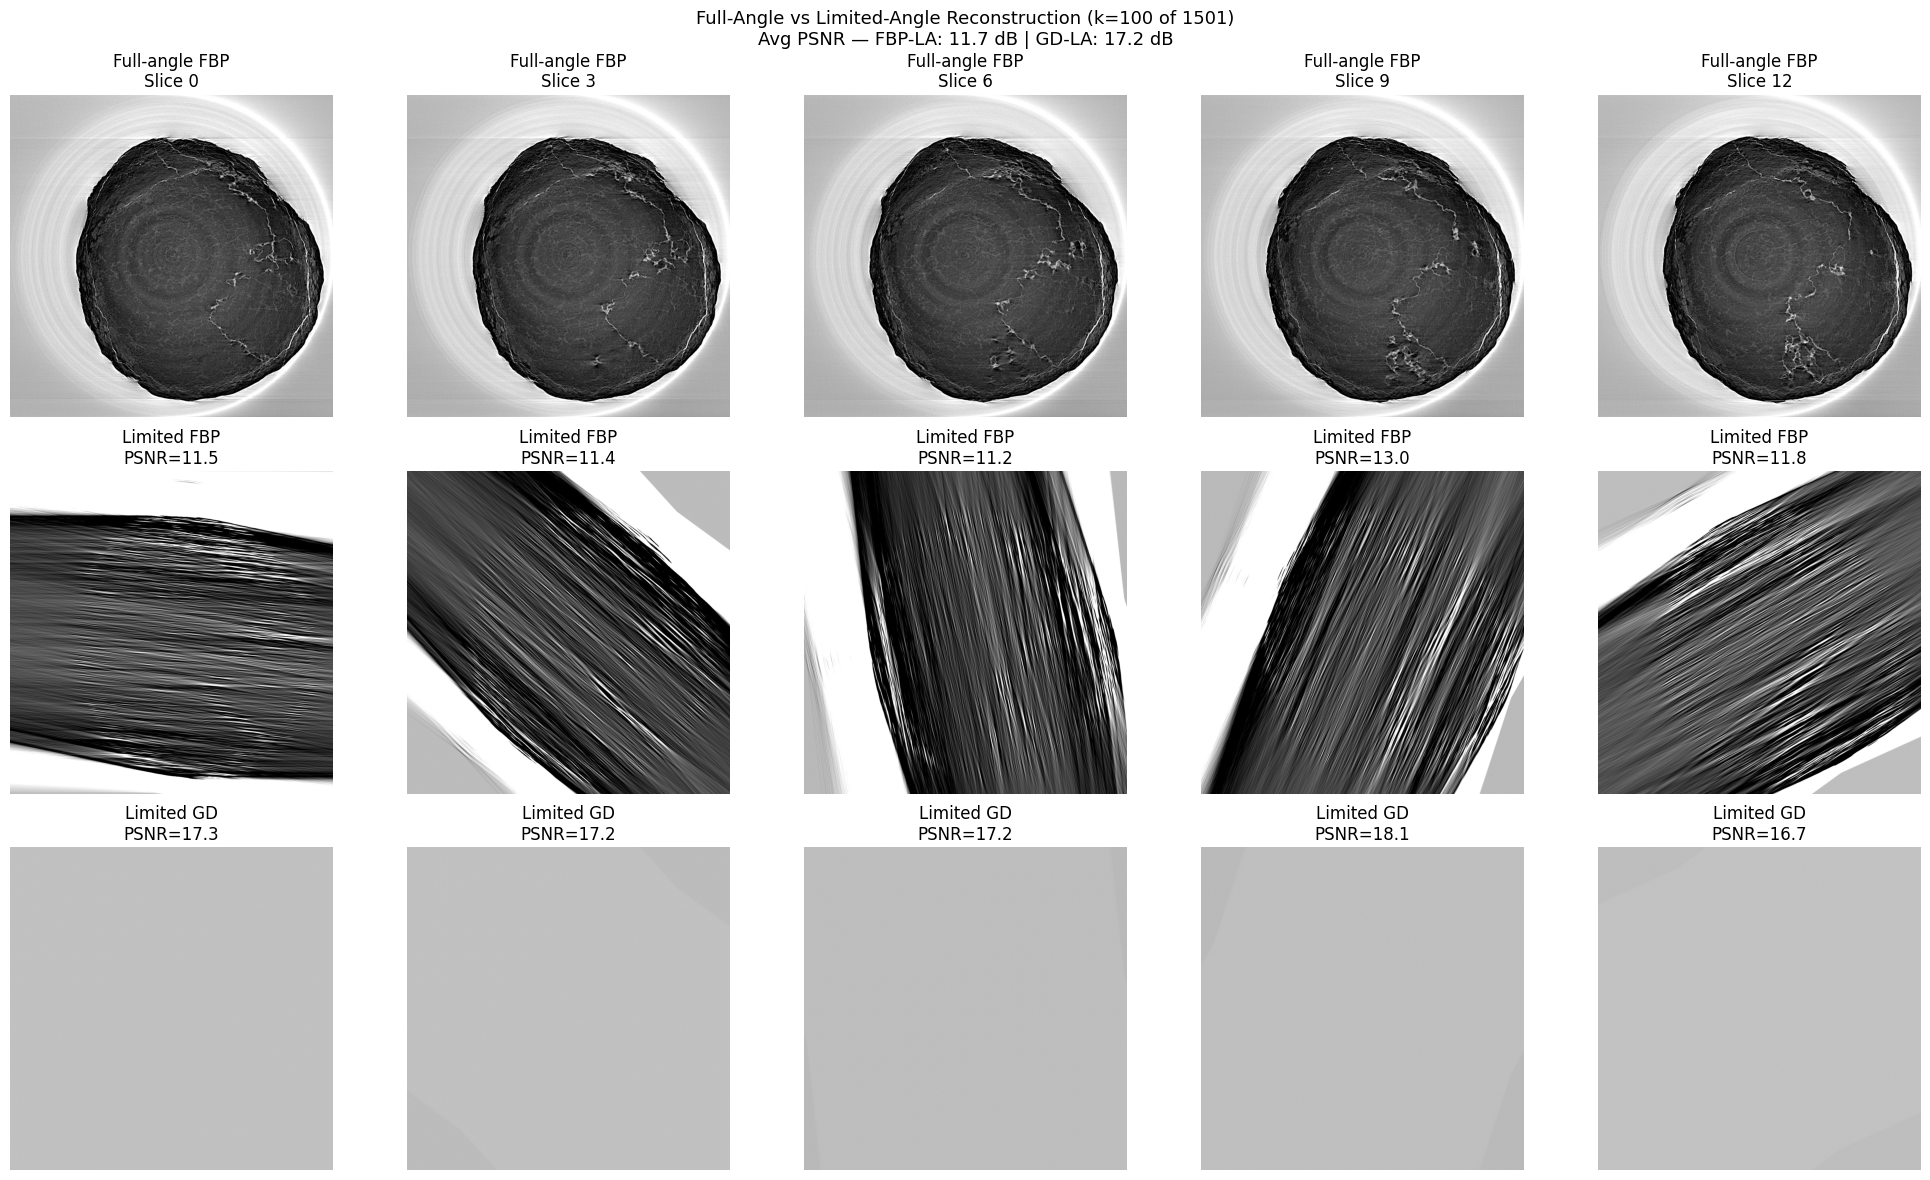

In [32]:
# ── Visual comparison: full vs limited-angle ──────────────────────────────
n_show = min(5, N_SLICES)
fig, axes = plt.subplots(3, n_show, figsize=(4 * n_show, 12))

for j in range(n_show):
    idx = j * (N_SLICES // n_show) if n_show < N_SLICES else j
    ref = full_recons[idx].numpy()
    vmin, vmax = np.percentile(ref, [2, 98])
    
    axes[0, j].imshow(ref, cmap='gray', vmin=vmin, vmax=vmax)
    axes[0, j].set_title(f'Full-angle FBP\nSlice {idx}')
    axes[0, j].axis('off')
    
    fbp_la = limited_fbp_recons[idx].numpy()
    axes[1, j].imshow(fbp_la, cmap='gray', vmin=vmin, vmax=vmax)
    m = metrics[idx]
    axes[1, j].set_title(f'Limited FBP\nPSNR={m["psnr_fbp_la"]:.1f}')
    axes[1, j].axis('off')
    
    gd_la = limited_gd_recons[idx].numpy()
    axes[2, j].imshow(gd_la, cmap='gray', vmin=vmin, vmax=vmax)
    axes[2, j].set_title(f'Limited GD\nPSNR={m["psnr_gd_la"]:.1f}')
    axes[2, j].axis('off')

plt.suptitle(
    f'Full-Angle vs Limited-Angle Reconstruction (k={K_ANGLES} of {N_proj})\n'
    f'Avg PSNR — FBP-LA: {avg_psnr_fbp:.1f} dB | GD-LA: {avg_psnr_gd:.1f} dB',
    fontsize=13,
)
plt.tight_layout()
plt.show()

## 8. Sinogram Coverage Visualisation

Show which angles each slice has access to — the contiguous blocks wrapping around.

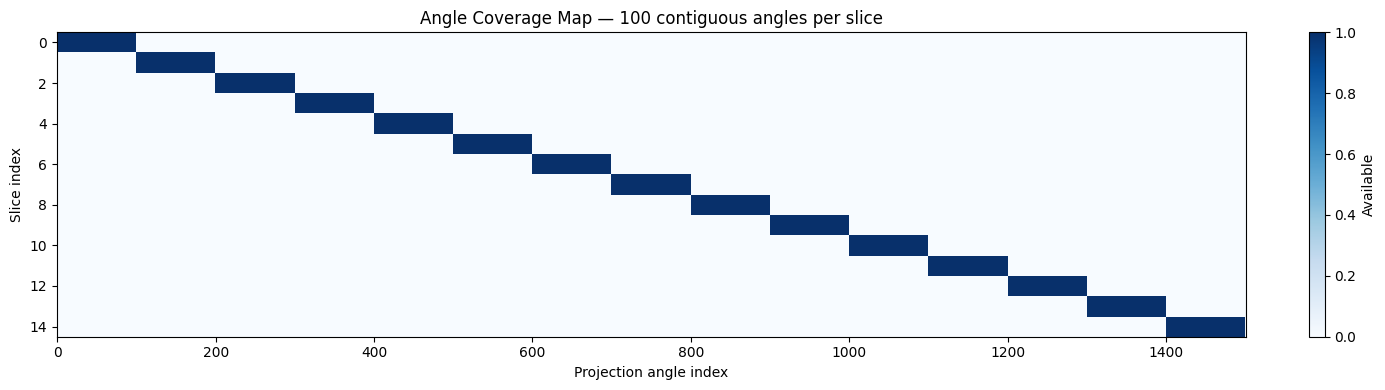

In [33]:
# ── Angle coverage map ────────────────────────────────────────────────────
coverage = np.zeros((N_SLICES, N_proj), dtype=float)
for i, idx in enumerate(la_dataset.slice_angle_indices):
    coverage[i, idx] = 1.0

fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(coverage, aspect='auto', cmap='Blues', interpolation='nearest')
ax.set_xlabel('Projection angle index')
ax.set_ylabel('Slice index')
ax.set_title(f'Angle Coverage Map — {K_ANGLES} contiguous angles per slice')
plt.colorbar(ax.images[0], ax=ax, label='Available', fraction=0.02)
plt.tight_layout()
plt.show()

## 9. Error Maps: Full vs Limited

Visualise the spatial error distribution for limited-angle reconstructions.

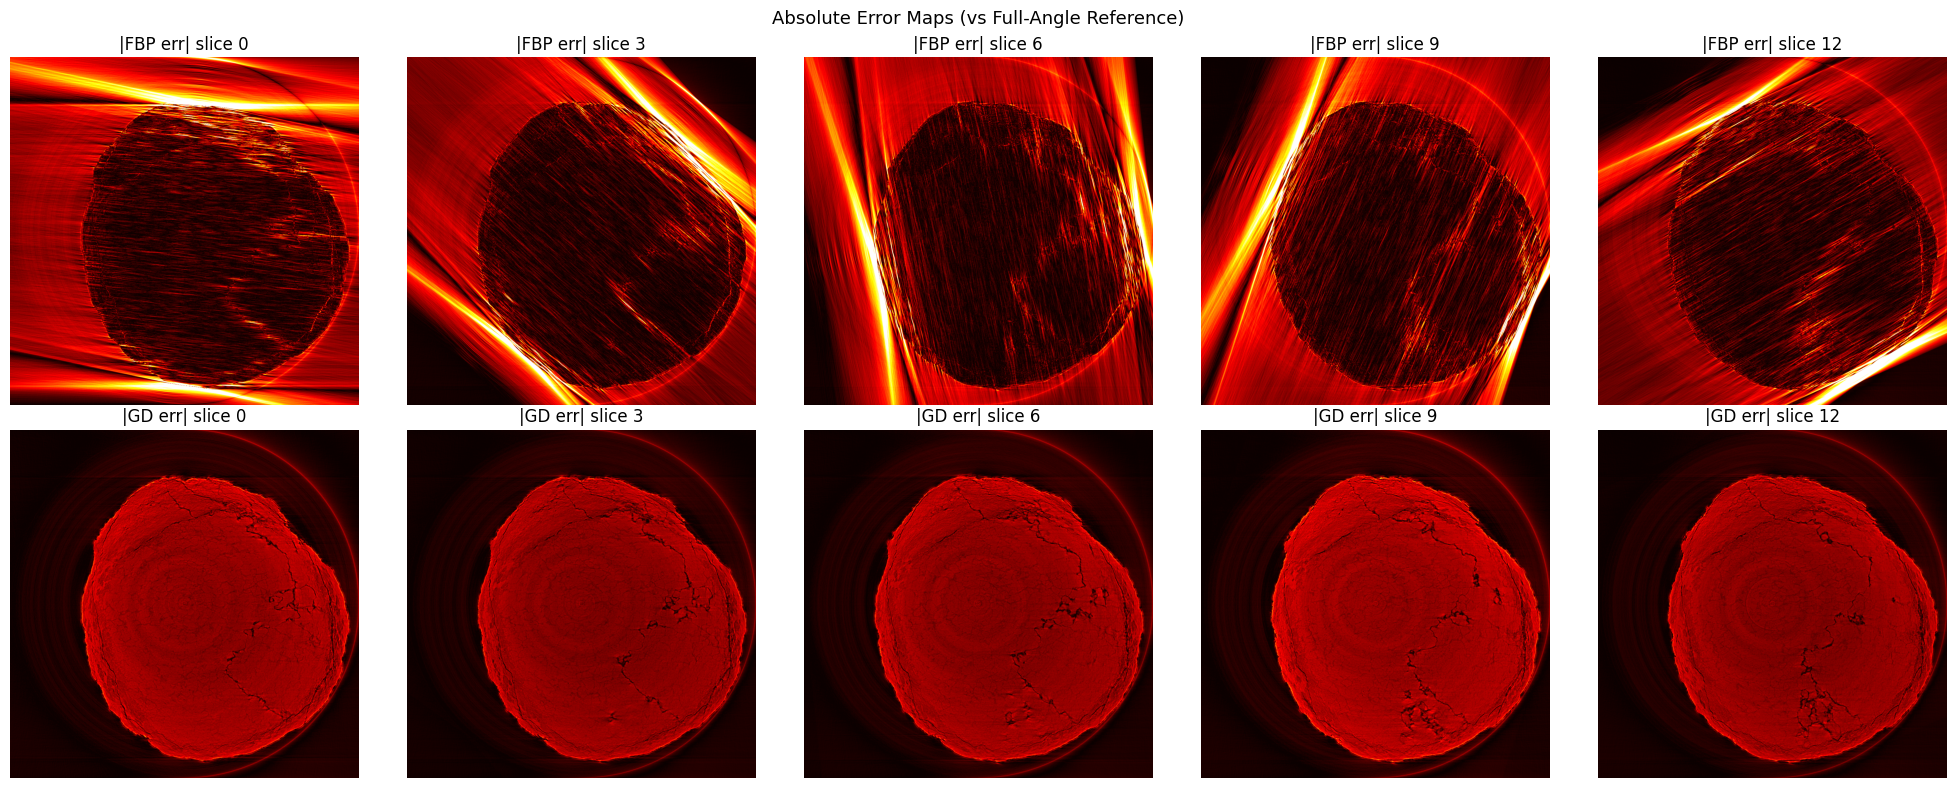

In [34]:
# ── Error maps ────────────────────────────────────────────────────────────
n_show = min(5, N_SLICES)
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))

for j in range(n_show):
    idx = j * (N_SLICES // n_show) if n_show < N_SLICES else j
    ref = full_recons[idx].numpy()
    fbp_la = limited_fbp_recons[idx].numpy()
    gd_la = limited_gd_recons[idx].numpy()
    
    err_fbp = np.abs(fbp_la - ref)
    err_gd = np.abs(gd_la - ref)
    emax = max(np.percentile(err_fbp, 99), np.percentile(err_gd, 99))
    
    axes[0, j].imshow(err_fbp, cmap='hot', vmin=0, vmax=emax)
    axes[0, j].set_title(f'|FBP err| slice {idx}')
    axes[0, j].axis('off')
    
    axes[1, j].imshow(err_gd, cmap='hot', vmin=0, vmax=emax)
    axes[1, j].set_title(f'|GD err| slice {idx}')
    axes[1, j].axis('off')

plt.suptitle('Absolute Error Maps (vs Full-Angle Reference)', fontsize=13)
plt.tight_layout()
plt.show()

## 10. SIRT Comparison (Optional)

Run SIRT on the limited-angle data for comparison.

In [35]:
# ── Limited-angle SIRT reconstruction ─────────────────────────────────────
SIRT_ITERS = 100
limited_sirt_recons = []

print(f"Limited-angle SIRT ({SIRT_ITERS} iters): {K_ANGLES} angles per slice …")
t0 = time.time()

for i in range(N_SLICES):
    sino_limited = la_dataset.limited_sinograms[i].to(device)  # (k, W)
    sino_vrc = sino_limited.unsqueeze(1)                        # (k, 1, W)
    angles_limited = la_dataset.slice_angles_deg[i]
    
    recon_3d = sirt_reconstruction_masked(
        projs_vrc=sino_vrc,
        angles_deg=angles_limited,
        lamino_angle_deg=LAMINO_ANGLE_DEG,
        vol_shape=vol_shape_3d,
        det_spacing_mm=config.det_spacing_mm,
        num_iterations=SIRT_ITERS,
        min_constraint=0.0,
        device=device,
    )
    limited_sirt_recons.append(recon_3d[0].cpu())

elapsed_sirt = time.time() - t0
limited_sirt_recons = torch.stack(limited_sirt_recons, dim=0)
print(f"✅ Limited-angle SIRT done in {elapsed_sirt:.1f}s")

# ── Metrics ───────────────────────────────────────────────────────────────
print(f"\n{'Slice':>6}  {'SIRT PSNR':>10}  {'SIRT SSIM':>10}")
print("-" * 30)
sirt_psnrs, sirt_ssims = [], []
for i in range(N_SLICES):
    ref = full_recons[i].numpy()
    sirt_la = limited_sirt_recons[i].numpy()
    p = compute_psnr(sirt_la, ref)
    s = compute_ssim(sirt_la, ref)
    sirt_psnrs.append(p)
    sirt_ssims.append(s)
    print(f"{i:>6d}  {p:>10.2f}  {s:>10.4f}")

print("-" * 30)
print(f"{'AVG':>6}  {np.mean(sirt_psnrs):>10.2f}  {np.mean(sirt_ssims):>10.4f}")

Limited-angle SIRT (100 iters): 100 angles per slice …
✅ Limited-angle SIRT done in 4.9s

 Slice   SIRT PSNR   SIRT SSIM
------------------------------
     0       13.32     -0.0961
     1       12.80     -0.0766
     2       12.60     -0.0804
     3       12.66     -0.0840
     4       12.55     -0.0757
     5       12.35     -0.0513
     6       12.96     -0.0701
     7       13.03     -0.0740
     8       12.65     -0.0631
     9       13.56     -0.0535
    10       13.36     -0.0493
    11       12.25     -0.0503
    12       12.15     -0.0637
    13       12.66     -0.0801
    14       12.83     -0.0961
------------------------------
   AVG       12.78     -0.0710


## 11. Summary

| Method | Avg PSNR | Avg SSIM | Notes |
|--------|----------|----------|-------|
| Full-angle FBP | (reference) | (reference) | 1501 projections |
| Limited FBP | ? | ? | k contiguous angles |
| Limited SIRT | ? | ? | k contiguous angles, 100 iter |
| Limited GD | ? | ? | k contiguous angles, Adam |

The limited-angle reconstructions should show characteristic artifacts (streaks in missing-angle directions). The GD reconstruction with non-negativity should be somewhat better than FBP.

**Next step:** Use Gaussian splatting as a learned prior to improve limited-angle reconstruction via the `GSplat_TimeResolved_CT` notebook.

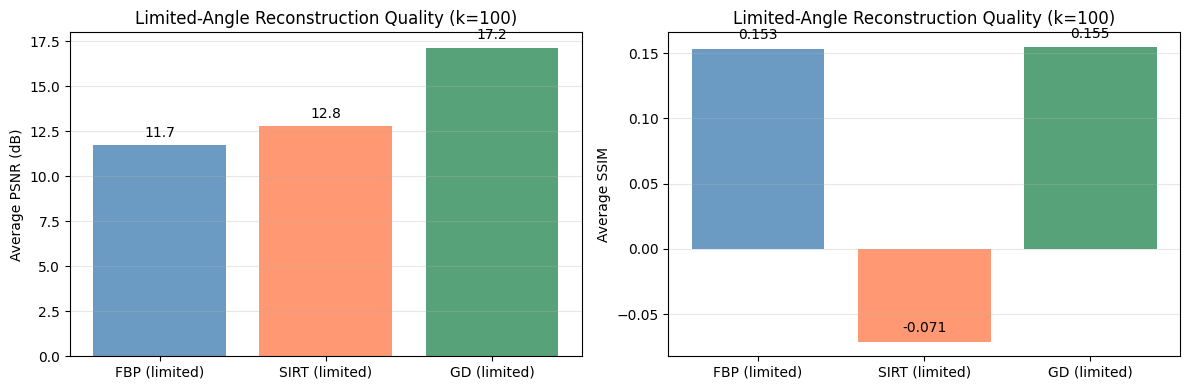


✅ Sanity checks complete. Proceed to GSplat_TimeResolved_CT notebook.


In [36]:
# ── Final comparison bar chart ────────────────────────────────────────────
methods = ['FBP (limited)', 'SIRT (limited)', 'GD (limited)']
avg_psnrs = [avg_psnr_fbp, np.mean(sirt_psnrs), avg_psnr_gd]
avg_ssims_list = [avg_ssim_fbp, np.mean(sirt_ssims), avg_ssim_gd]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

bars1 = ax1.bar(methods, avg_psnrs, color=['steelblue', 'coral', 'seagreen'], alpha=0.8)
ax1.set_ylabel('Average PSNR (dB)')
ax1.set_title(f'Limited-Angle Reconstruction Quality (k={K_ANGLES})')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars1, avg_psnrs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val:.1f}', ha='center', va='bottom', fontsize=10)

bars2 = ax2.bar(methods, avg_ssims_list, color=['steelblue', 'coral', 'seagreen'], alpha=0.8)
ax2.set_ylabel('Average SSIM')
ax2.set_title(f'Limited-Angle Reconstruction Quality (k={K_ANGLES})')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars2, avg_ssims_list):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print("\n✅ Sanity checks complete. Proceed to GSplat_TimeResolved_CT notebook.")